# GNN–GA–LP: đọc và chạy bản tái hiện phương pháp
Bài arXiv:2608.10245v1. **Dữ liệu/checkpoint dưới đây do repo tạo, không phải bộ dữ liệu hoặc trọng số tác giả.** Notebook mở kết quả đã chạy 20 seed; cell cuối cho phép chạy lại toàn bộ.

In [1]:
from pathlib import Path
import os, sys, subprocess
if not Path('supply_chain/optimization.py').exists():
    if Path('../supply_chain/optimization.py').exists():
        os.chdir('..')
    else:
        if not Path('/content/gnn/supply_chain/optimization.py').exists():
            subprocess.run(['git','clone','https://github.com/dungTudonghoa/gnn.git','/content/gnn'],check=True)
        os.chdir('/content/gnn')
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0,str(Path.cwd()))
if 'google.colab' in sys.modules:
    subprocess.run([sys.executable,'-m','pip','install','-q','-r','supply_chain/requirements.txt'],check=True)

## 1. Input: danh sách thông số và ma trận chi phí
Một instance là một graph. Các mảng là cách lưu đồ thị và thuộc tính, không cần ảnh đồ thị để train.

In [2]:
import json
import numpy as np
import torch
from supply_chain.data import Instance
root = Path('supply_chain/results/reconstruction')
d = Instance.load(root/'instances/reconstructed-test-01.json')
print('Factories / hubs / retailers:',d.shape)
print('Capacity:',d.capacity)
print('Demand first 5:',d.demand[:5])
print('Supply cost first 3 hubs:',d.supply_cost[:,:3])

Factories / hubs / retailers: (3, 10, 25)
Capacity: [1366.47722934  903.3413542   807.58064222]
Demand first 5: [113.59590849 109.95863275  94.67367103 112.71743304 105.65401706]
Supply cost first 3 hubs: [[125.4533483  114.39840924 134.56324234]
 [ 90.38781951  99.05702853  94.79066088]
 [121.25980382 126.08853564 129.14681779]]


## 2. Biến thông số thành graph
Factory–hub, hub–factory, hub–retailer, retailer–hub và hub–hub là năm loại cạnh. Chuẩn hóa dùng thống kê train đã lưu trong checkpoint, không fit lại trên test.

In [3]:
from supply_chain.gnn import AssignmentGNN, Standardizer, probabilities
torch.set_num_threads(1)
checkpoint = torch.load(root/'model.pt',map_location='cpu',weights_only=True)
model = AssignmentGNN(checkpoint['hidden'],checkpoint['rounds'])
model.load_state_dict(checkpoint['state_dict'])
norm = Standardizer.from_state(checkpoint['normalizer'])
nodes,edges,eligible = norm.transform(d)
print('Node feature shapes:',{k:tuple(v.shape) for k,v in nodes.items()})
print('Edges (index, attributes):',{k:(tuple(i.shape),tuple(a.shape)) for k,(i,a) in edges.items()})

Node feature shapes: {'factory': (3, 5), 'hub': (10, 8), 'retailer': (25, 4)}
Edges (index, attributes): {'fh': ((2, 30), (30, 3)), 'hf': ((2, 30), (30, 3)), 'hr': ((2, 250), (250, 1)), 'rh': ((2, 250), (250, 1)), 'hh': ((2, 90), (90, 1))}


## 3. Output GNN: xác suất chọn factory cho mỗi hub
Mỗi cột có tổng bằng 1. Đây chưa phải lượng hàng tối ưu.

In [4]:
p = probabilities(model,norm,d)
print('p shape:',p.shape)
print(np.round(p[:,:5],3))
print('Column sums:',p.sum(0))
print('Greedy assignment:',p.argmax(0))

p shape: (3, 10)
[[0.413 0.071 0.055 0.205 0.306]
 [0.445 0.867 0.815 0.397 0.138]
 [0.142 0.062 0.13  0.398 0.556]]
Column sums: [1.         1.         0.99999994 1.         1.         1.
 0.99999994 0.99999994 1.         1.        ]
Greedy assignment: [1 1 1 2 2 2 0 0 2 1]


## 4. Đọc một kết quả GA rồi giải LP cho flows
Tất cả scenario dùng cùng flows. Scenario reference là optimum của mô hình đầy đủ, không phải giá trị tốt nhất GA tìm thấy.

In [5]:
from supply_chain.optimization import FlowModel
runs = json.loads((root/'runs.json').read_text())
run = next(r for r in runs if r['instance']==d.name and r['formulation']=='regret' and r['method']=='gnn_ga' and r['budget']==75 and r['seed']==1001)
references = np.array(json.loads((root/'references.json').read_text())[d.name]['scenario_optima'])
lp = FlowModel(d)
solution = lp.solve_fixed(tuple(run['assignment']),references)
print('Assignment:',solution.assignment)
print('Factory-to-hub flow:',np.round(solution.flows[lp.qf],2))
print('Shortage:',np.round(solution.flows[lp.u],2))
print('Costs by scenario:',solution.scenario_costs)
print('Scenario optima:',references)
print('Regret:',solution.objective,'=',max(solution.scenario_costs-references))
print('Largest feasibility violation:',lp.residual(solution))
assert abs(solution.objective-run['objective']) < 1e-6

Assignment: (0, 1, 1, 2, 0, 2, 0, 0, 2, 1)
Factory-to-hub flow: [[248.21   0.     0.     0.   153.4    0.   287.09 164.88   0.     0.  ]
 [  0.   246.02 319.81   0.     0.     0.     0.     0.     0.   337.51]
 [  0.     0.     0.   278.88   0.   175.95   0.     0.   352.75   0.  ]]
Shortage: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]
Costs by scenario: [363246.08165672 446387.35709741 529528.6325381 ]
Scenario optima: [360236.42129864 443583.37234334 526553.84130008]
Regret: 3009.6603580764495 = 3009.6603580764495
Largest feasibility violation: 1.4210854715202004e-14


## 5. So sánh các phương pháp trên dữ liệu dựng lại
Biểu đồ biểu diễn mean ± sample SD. Các test dùng 20 seed ghép cặp; đường đỏ là reference MILP.

Search runs: 760
Selected epoch: 15
Validation: {'epoch': 15, 'train_loss': 0.2038891464471817, 'val_loss': 0.6829235394795735, 'val_accuracy': 0.6666666666666666}


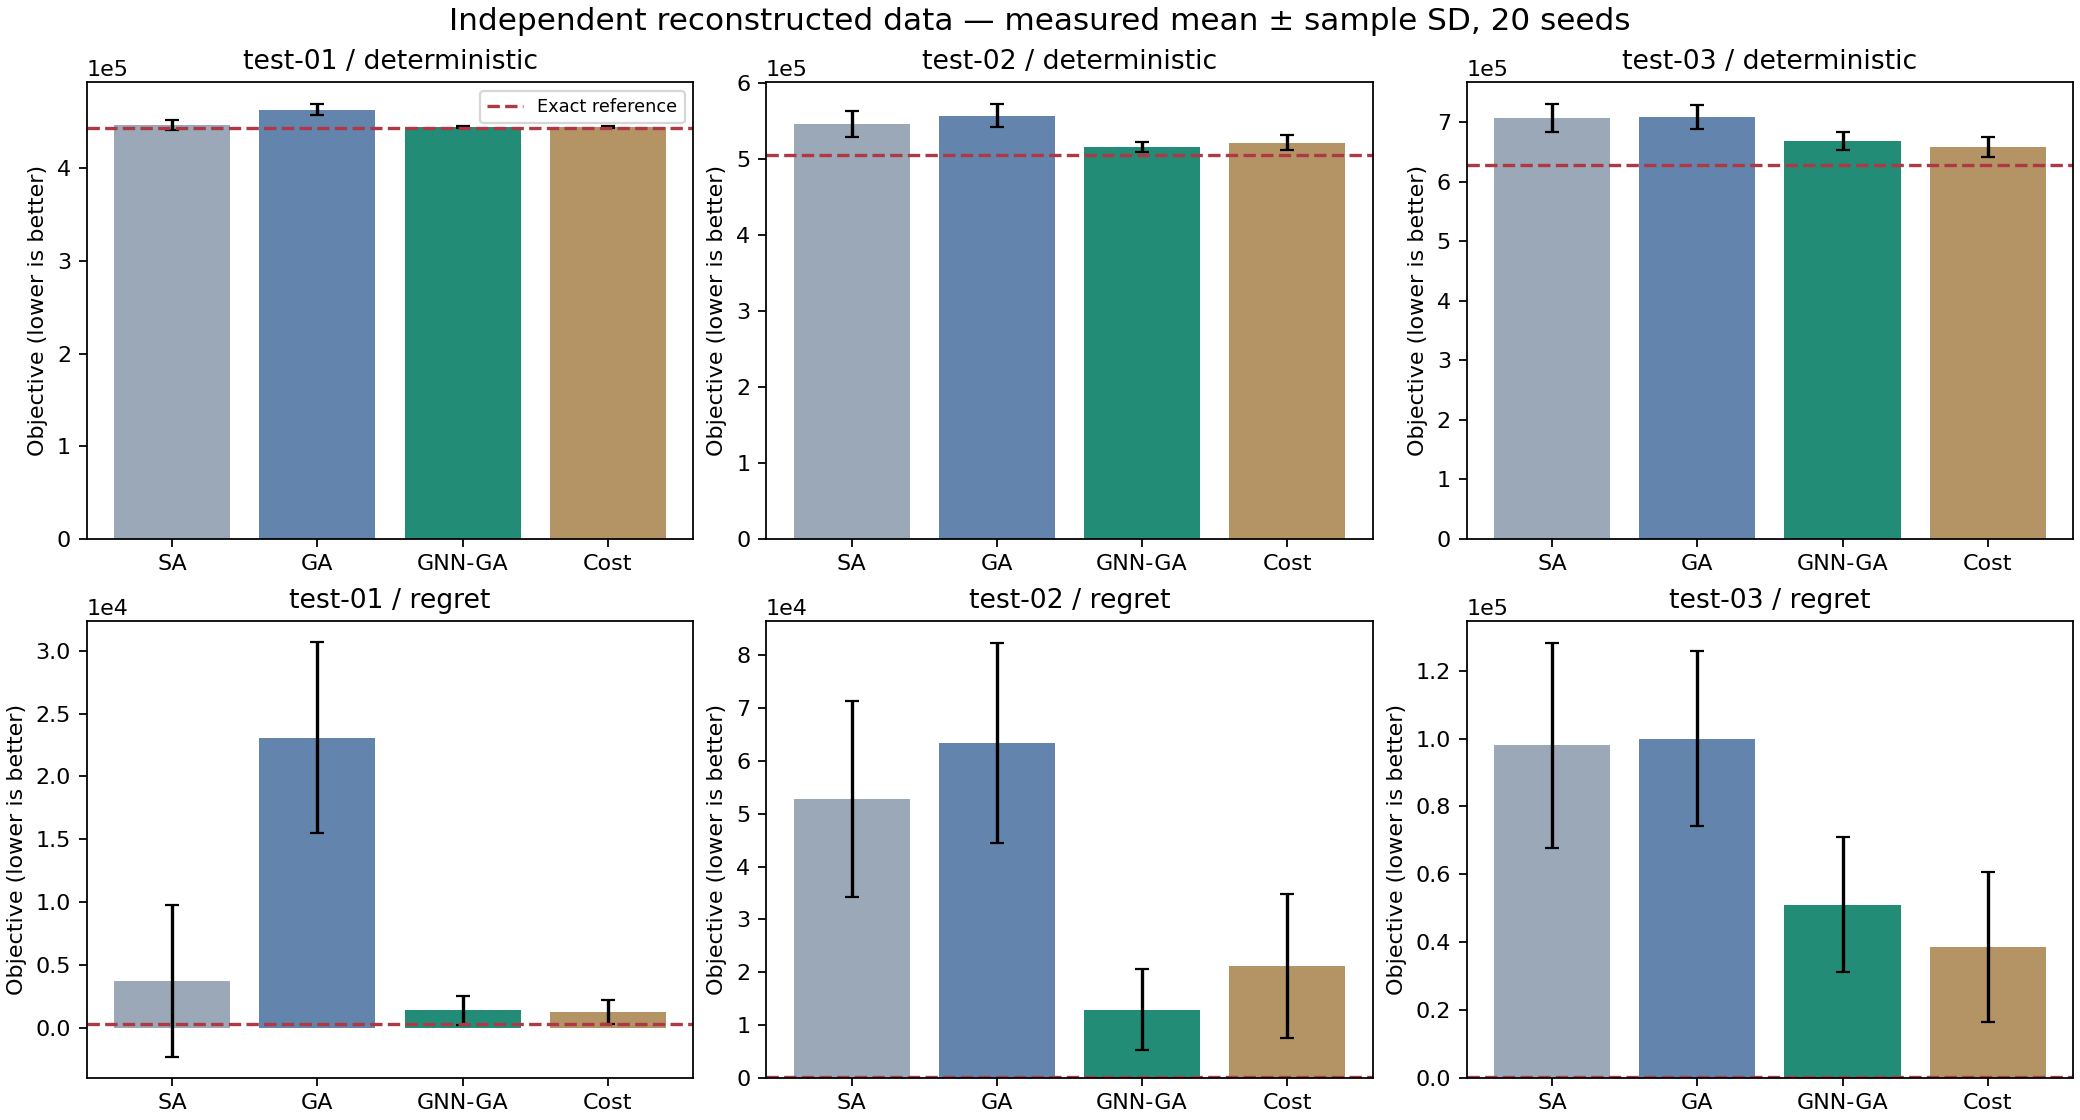

In [6]:
from IPython.display import Image, display, Markdown
display(Image(filename=str(root/'comparison.png')))
print('Search runs:',len(runs))
training = json.loads((root/'training.json').read_text())
print('Selected epoch:',training['best_epoch'])
print('Validation:',training['history'][training['best_epoch']-1])

## 6. Chạy lại khi cần
Đặt RUN_AGAIN=True để chạy toàn bộ 760 lượt vào thư mục mới. Không cần bật để đọc kết quả đã có. Thời gian phụ thuộc CPU.

In [7]:
RUN_AGAIN = False
if RUN_AGAIN:
    from supply_chain.experiment import execute
    from supply_chain.report import render
    execute('outputs/supply-chain-rerun')
    render('outputs/supply-chain-rerun')

## Cần gì để khớp bảng số liệu bài báo?
Dữ liệu instance gốc, generator đầy đủ, feature schema, trọng số và các quy tắc search còn thiếu. Xem [REPRODUCIBILITY.md](https://github.com/dungTudonghoa/gnn/blob/main/supply_chain/REPRODUCIBILITY.md). Các giá trị được chép từ Table IV nằm riêng trong paper_reported_results.json, không được trộn vào kết quả tính toán.